# Data Vis: Visualizing Numerical and Categorical Data
* Notebook 1: Visualizing Distributions

## Setup

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

## Data

In this notebook, we will use the NYC Flights 2013 dataset, which contains information about all domestic flights that departed from NYC in 2013. The dataset includes the following tables:
- `flights`: Contains information about each flight, including the origin and destination airports, departure and arrival times, and delays.
- `planes`: Contains information about the planes, including their tail numbers and model years.
- `airports`: Contains information about the airports, including their names and locations.
- `airlines`: Contains information about the airlines, including their names and IATA codes.
- `weather`: Contains information about the weather at the origin airports, including temperature, wind speed, and precipitation.

In [2]:
data = pd.read_csv('flights_joined.csv')

In [3]:
data.shape

(336776, 53)

In [4]:
data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,tzone_dest,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,America/Chicago,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,America/Chicago,39.92,24.98,54.81,250.0,14.96014,21.86482,0.0,1011.4,10.0
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,America/New_York,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,...,NaN,39.02,26.96,61.63,260.0,14.96014,NaN,0.0,1012.1,10.0
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,...,America/New_York,39.92,24.98,54.81,260.0,16.11092,23.01560,0.0,1011.7,10.0


## Histograms and Alternatives

Histograms are the most common way to visualize the distribution of a single numerical variable. They are useful for understanding the shape of the distribution, identifying outliers, and comparing distributions across different groups. We can use the figure-level function `displot()` to create a histogram. This function automatically creates a figure and axes for us, so we don't need to worry about creating them ourselves. The most crucial parameter is `bins`, which specifies the number of bins to use for the histogram.

Alternatively, we could use the axes-level function `histplot()` to create a histogram. This function requires us to create the figure and axes ourselves, but it gives us more control over the appearance of the plot.

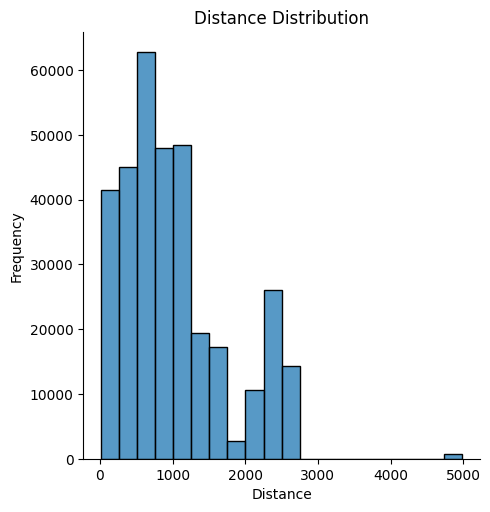

In [8]:
ax = sns.displot(data['distance'], kind="hist", bins=20)
ax.set(title='Distance Distribution', xlabel='Distance', ylabel='Frequency') # creating labels in one line!
plt.show()

We could also visualize the same distribution using a denisty plot by specifying `kind="kde"` in the `displot()` function.

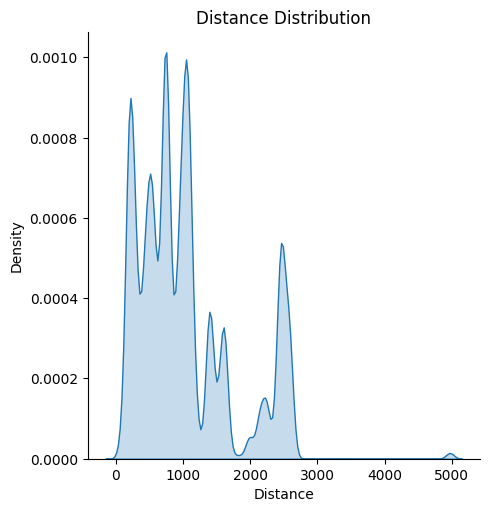

In [9]:
ax = sns.displot(data['distance'], kind="kde", fill=True)
ax.set(title='Distance Distribution', xlabel='Distance', ylabel='Density')
plt.show()

Histograms and density plots can be nicely arrange in small multiples by using the `FacetGrid` class. This allows us to compare the distributions of different groups in the dataset side by side. We can use the `col` parameter to specify the variable we want to use for the columns, and the `row` parameter to specify the variable we want to use for the rows.

To create small multiples, we first create a `FacetGrid` object by passing the data and the variables we want to use for the rows and columns. Then, we can use the `map()` method to apply a function to each facet. In this case, we will use the `kdeplot()` function to create a density plot for each facet.

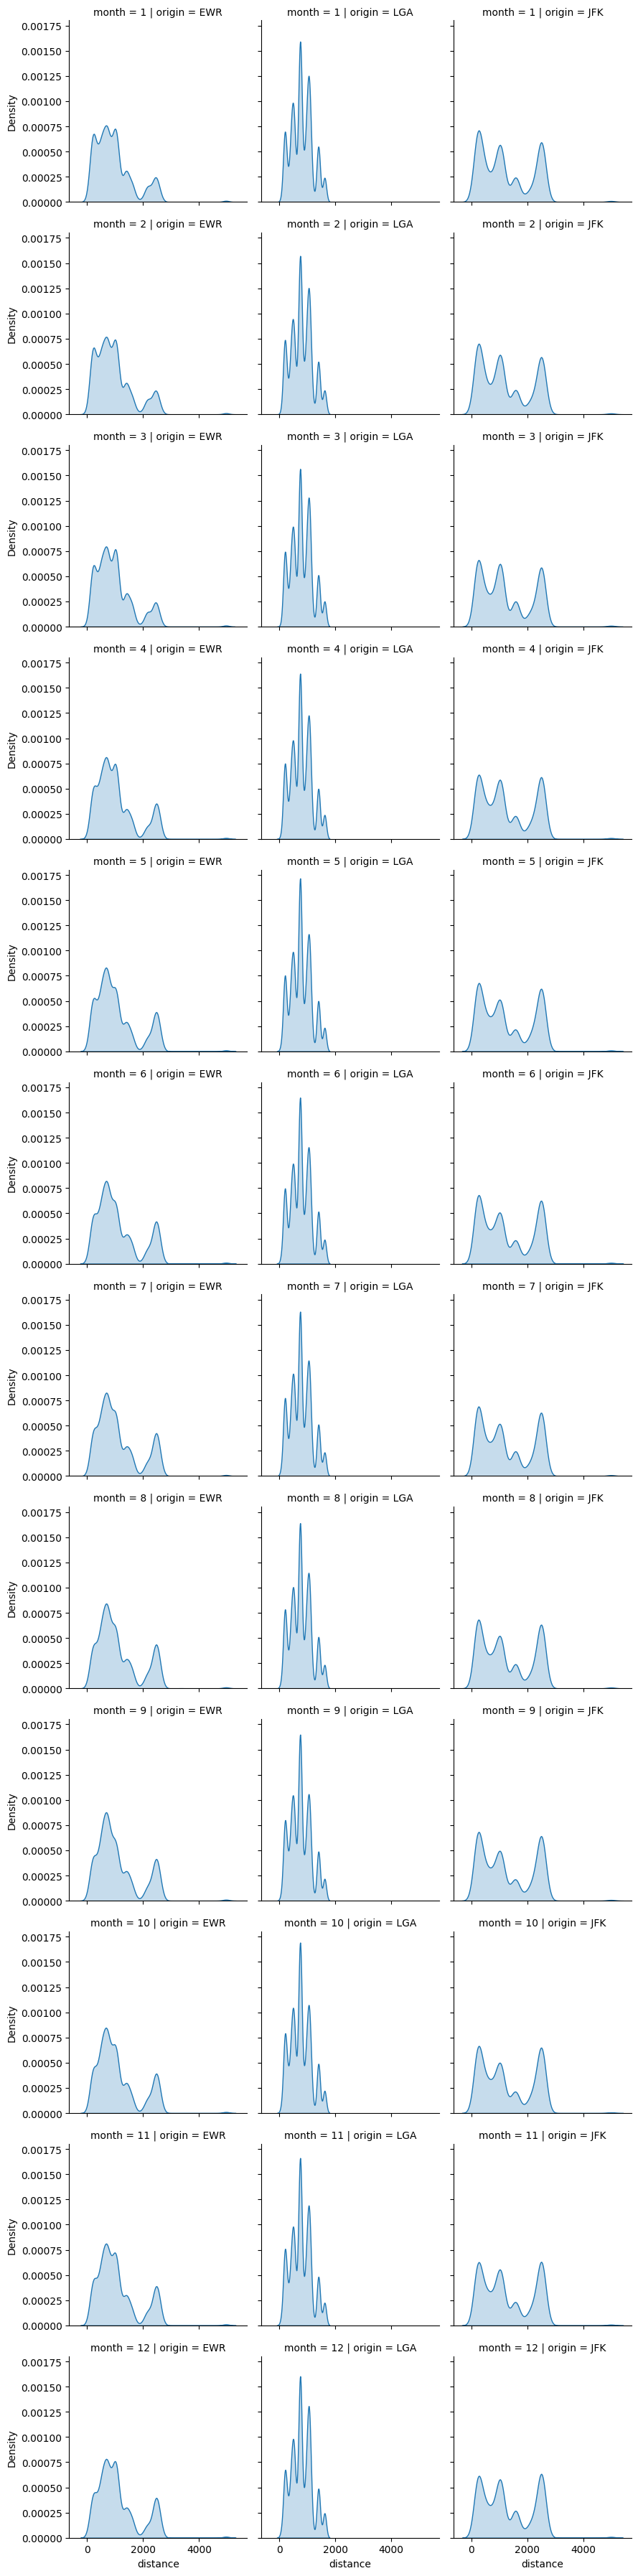

In [11]:
g = sns.FacetGrid(data, col="origin", row="month")
g.map(sns.kdeplot, "distance", fill=True)
plt.show()

Finally, we can also visualize the cumulative distribution function (CDF) using the `kind="ecdf"` parameter in the `displot()` function. The CDF is useful for understanding the proportion of data points that fall below a certain value.

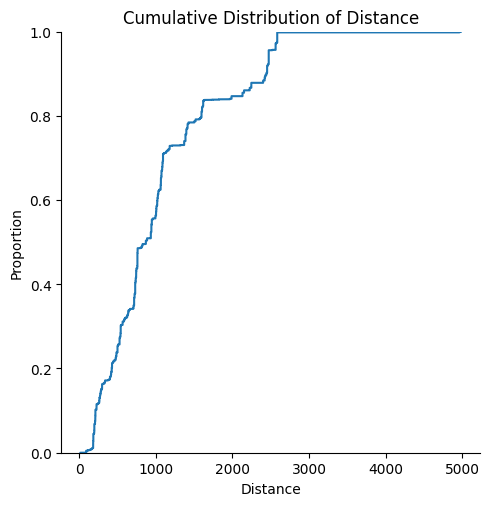

In [12]:
ax = sns.displot(data['distance'], kind="ecdf")
ax.set(title='Cumulative Distribution of Distance', xlabel='Distance', ylabel='Proportion')
plt.show()

Now it's your turn. Create historgams, density plots and cumulative distribution functions for other numerical variables in the dataset...

In [ ]:
# YOUR CODE HERE

## Box Plots and and Alternatives

I am a big fan of box plots to visualize distributions. Box plots show the median, quartiles, and outliers of the data in a compact way, making it easy to compare distributions across different groups. They are a great way to visualize the distribution of a numerical variable across different groups. 

Here, we will use the axes-level function `boxplot()` to create a box plot. This function gives you more control over the appearance of the plot.

In [ ]:
ax = sns.boxplot(y=data["distance"])
ax.set(title='Boxplot of Distance', ylabel='Distance')
plt.show()

You can easily create box plots per group by using the `y` parameter. 

In [ ]:
ax = sns.boxplot(x=data["origin"], y=data["distance"])
ax.set(title='Boxplot of Distance by Origin', xlabel='Origin', ylabel='Distance')
plt.show()

The box of a box plot can hide interesting information about the distribution of the data. For example, if the data is not normally distributed, the box plot may not accurately represent the distribution. In such cases, it may be more informative to use a violin plot using `violinplot()`, which shows the kernel density estimate of the data along with the box plot.

In [ ]:
ax = sns.violinplot(x=data["origin"], y=data["distance"])
ax.set(title='Violin Plot of Distance by Origin', xlabel='Origin', ylabel='Distance')
plt.show()

Another drawback of box plots is that they are hidding how many data points are in each group. To visualize the distribution of the data points, we can use the `swarmplot()` function instead. Yet, these plots can be crowded when there are many data points (note that we are randomly sampling 300 data points in this example).

In [ ]:
sns.swarmplot(x="origin", y="distance", data=data.sample(300), size=3)
plt.title("Swarm Plot of Distance by Origin")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

Now it's your turn. Create box plots, violin plots and swarm plots for other numerical variables in the dataset...

In [ ]:
# YOUR CODE HERE